# Chronos-2 Quality Net — Train/Val Loss Curves & Overfitting Check (2026-08-19~21, v2)

`predlen4 full fine-tuning` context_length 스윕 전체(**24**/73/128/168/256/384/512/768/1024/**1280**/
**1536**, blaine+residue = 22개 run)의 **train loss vs val loss 곡선**을 한 노트북에 모아서
overfitting 여부를 확인합니다.

이 버전(`_v2` 체크포인트)은 이전 버전의 두 가지 문제를 고치고 다시 학습한 결과입니다:
1. **불완전한 기록 문제 해결** — 예전에는 `checkpoint-N/trainer_state.json`을 읽었는데,
   `Chronos2Pipeline.fit()`이 내부적으로 강제하는 `save_total_limit=1` + `load_best_model_at_end=True`
   때문에 val_loss가 가장 좋았던 체크포인트 하나만 남고 그 이후(또는 그 전) 기록이 삭제/누락되는 경우가
   있었습니다(예: blaine ctx=73, residue ctx=128/168은 점이 딱 1개뿐이었음). `_v2`는
   `eval/loss_history.py`의 `make_loss_history_callback()`으로 학습 도중 실시간으로 모든 로그를
   기록하기 때문에, 어떤 체크포인트가 디스크에서 지워지든 상관없이 **완전한 곡선**입니다(전부 10개
   지점, `--num-steps 1000` / `eval_steps=100` 기준).
2. **ctx=24를 predlen=4로 통일** — 예전 ctx=24는 predlen=1로 학습되어 나머지(전부 predlen=4)와 비교할
   수 없었는데, `_v2`는 ctx=24도 predlen=4로 다시 학습해서 9개 구간을 전부 동일한 기준으로 비교할 수
   있습니다.
3. **1536 추가(2026-08-21)** — 512/768/1024가 계속 좋아지는 추세라 한 단계 더 늘려서 추세가 이어지는지
   확인. 2048도 5-step 스모크 테스트는 해봤으나 이 GPU(8.5GB)에서 step당 시간이 1024 대비 ~8배로 튀어서
   (1.6초 → 12.4초) 정식 학습은 보류.
4. **1280 추가(2026-08-21, 같은 날)** — 1536에서 blaine만 불안정해진 걸 보고, 1024(안정)와 1536(불안정)
   사이 어디서 경계가 생기는지 좁혀보려고 추가.

`loss_history.csv`(콜백이 기록한 원본, `checkpoints/{target}_full_predlen4_ctx{ctx}_v2/`)만 읽고 GPU는
다시 쓰지 않습니다.

In [1]:
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    raise RuntimeError(
        f"config.py를 {ROOT} 에서 찾지 못했습니다. Jupyter를 chronos_quality_net 폴더에서 실행하거나, "
        "이 노트북을 그 폴더로 옮겨서 다시 여세요."
    )
sys.path.insert(0, str(ROOT))

from eval.loss_history import overfit_summary, plot_loss_history

TARGETS = ["blaine", "residue"]
CTX_VALUES = [24, 73, 128, 168, 256, 384, 512, 768, 1024, 1280, 1536]
# 1536 added 2026-08-21: 2048 was also smoke-tested (5 steps) but step time jumped ~8x vs 1024
# (this 8.5GB GPU has little headroom past ~1024) -- not worth a full 1000-step run right now.
# 1280 added 2026-08-21 (same day): blaine was stable at 1024 but not at 1536, so this narrows
# down where the instability actually starts -- see conclusion.


def ckpt_dir(target: str, ctx: int) -> Path:
    return ROOT / "checkpoints" / f"{target}_full_predlen4_ctx{ctx}_v2"

## 1. Overfitting 요약 테이블

- `n_val`: 이 run에 기록된 평가(eval) 지점 개수 — `_v2`는 콜백이 실시간으로 다 기록하므로 전부 10개여야
  정상(`--num-steps 1000` / `eval_steps=100`).
- `val_final_minus_min`: **이번엔 구조적으로 0이 되지 않는 진짜 신호입니다** (예전 `_v2` 이전 버전은
  살아남은 체크포인트 자체가 항상 최저점이라 이 값이 항상 0이었음). 0보다 크면 val loss가 학습 도중
  최저점을 찍고 다시 올라갔다는 뜻 — 값이 클수록 overfitting이 뚜렷합니다.

In [2]:
import pandas as pd

rows = []
loss_dfs = {}  # (target, ctx) -> DataFrame, reused by the plotting cell below
for target in TARGETS:
    for ctx in CTX_VALUES:
        d = ckpt_dir(target, ctx)
        csv_path = d / "loss_history.csv"
        if not csv_path.exists():
            rows.append({"target": target, "ctx": ctx, "error": f"missing {csv_path}"})
            continue
        df = pd.read_csv(csv_path)
        loss_dfs[(target, ctx)] = df
        s = overfit_summary(df)
        rows.append(
            {
                "target": target,
                "ctx": ctx,
                "n_val": s.get("n_val_points"),
                "val_min": s.get("val_loss_min"),
                "val_min_step": s.get("val_loss_min_step"),
                "val_final": s.get("val_loss_final"),
                "val_final_minus_min": s.get("final_minus_min"),
            }
        )

summary_table = pd.DataFrame(rows).sort_values(["target", "ctx"]).reset_index(drop=True)
summary_table

,target,ctx,n_val,val_min,val_min_step,val_final,val_final_minus_min
0,blaine,24,10,0.027610,300,0.027894,0.000284
1,blaine,73,10,0.023437,100,0.025994,0.002557
2,blaine,128,10,0.025282,100,0.026501,0.001220
3,blaine,168,10,0.024177,900,0.024220,0.000043
4,blaine,256,10,0.027473,200,0.027757,0.000285
5,blaine,384,10,0.025584,900,0.025735,0.000151
6,blaine,512,10,0.024438,1000,0.024438,0.000000
7,blaine,768,10,0.020559,900,0.020668,0.000110
8,blaine,1024,10,0.018582,1000,0.018582,0.000000
9,blaine,1280,10,0.016818,1000,0.016818,0.000000


## 2. Train vs Val Loss 곡선 (context_length별)

빨간 점선 = val_loss 최저점. 이번엔 그 점 앞뒤 전체가 다 진짜 관측 데이터입니다.

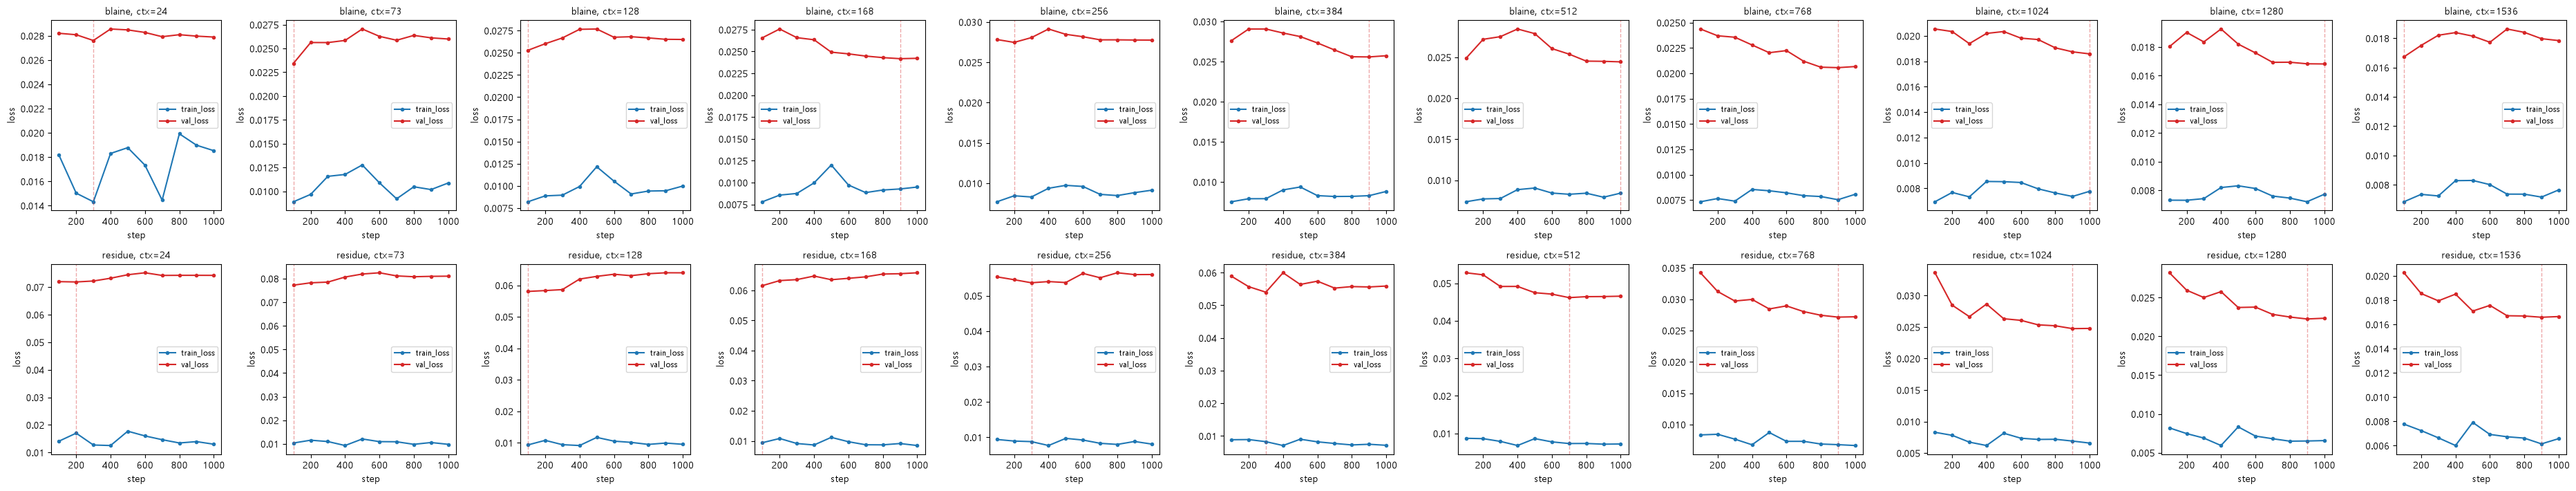

In [3]:
fig, axes = plt.subplots(len(TARGETS), len(CTX_VALUES), figsize=(3.4 * len(CTX_VALUES), 3.6 * len(TARGETS)))

for row, target in enumerate(TARGETS):
    for col, ctx in enumerate(CTX_VALUES):
        ax = axes[row, col]
        df = loss_dfs.get((target, ctx))
        if df is None:
            ax.set_visible(False)
            continue
        plot_loss_history(df, ax=ax, title=f"{target}, ctx={ctx}")

fig.tight_layout()
plt.show()

## 3. Context length별로 따로 보기 (위 그리드가 너무 작아서 확대)

위 9×2 그리드는 subplot이 너무 작아서 알아보기 어려우므로, 같은 데이터를 context_length 하나당
하나의 큰 figure(blaine/residue 나란히)로 나눠서 다시 그립니다. `loss_dfs`는 위 셀에서 이미 로드해둔
것을 재사용하므로 GPU/디스크 IO 추가 없이 바로 그립니다.

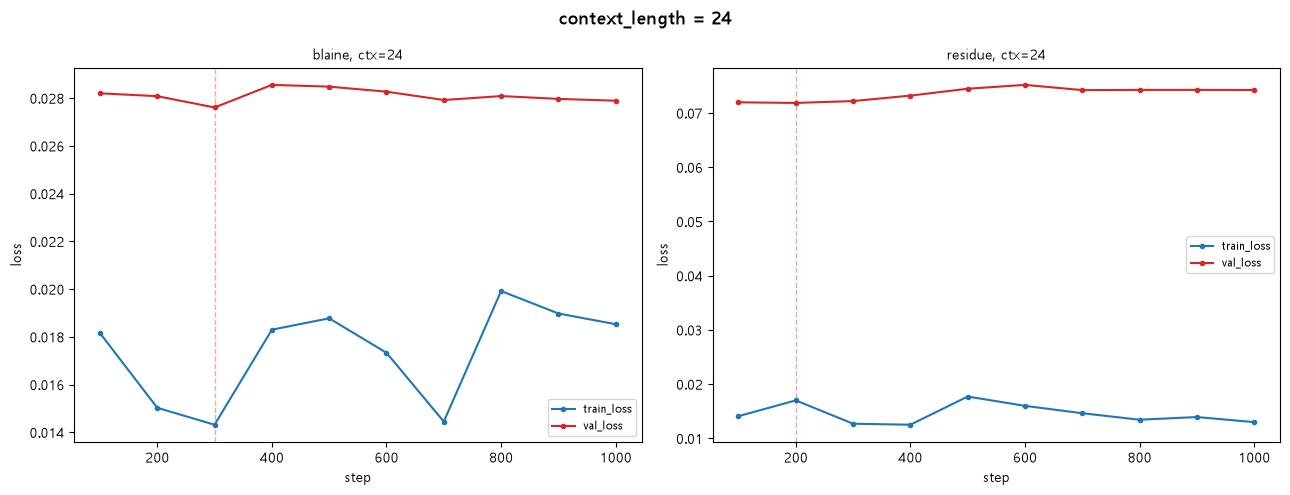

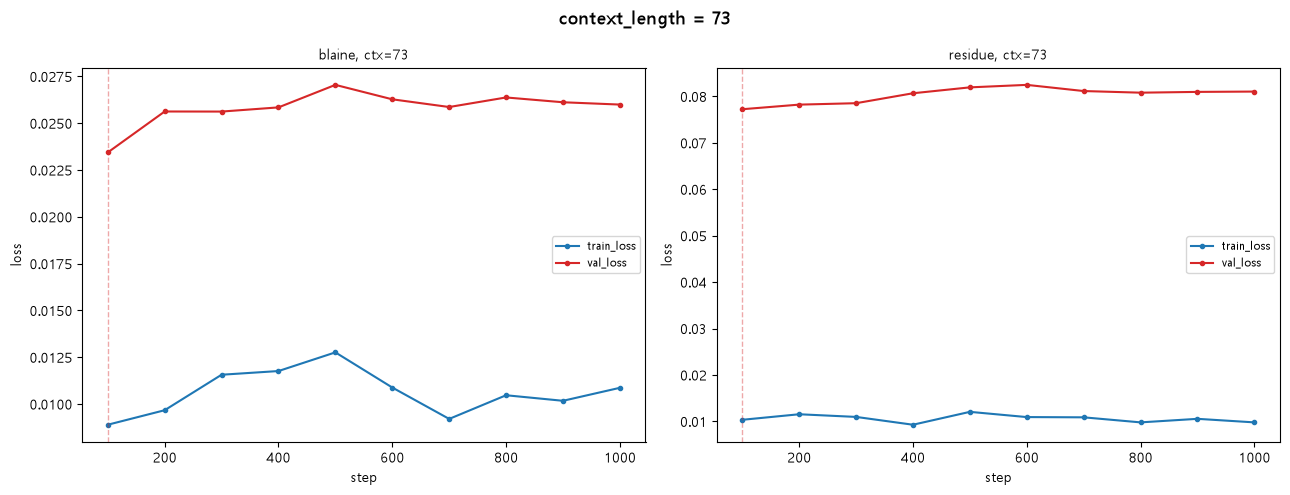

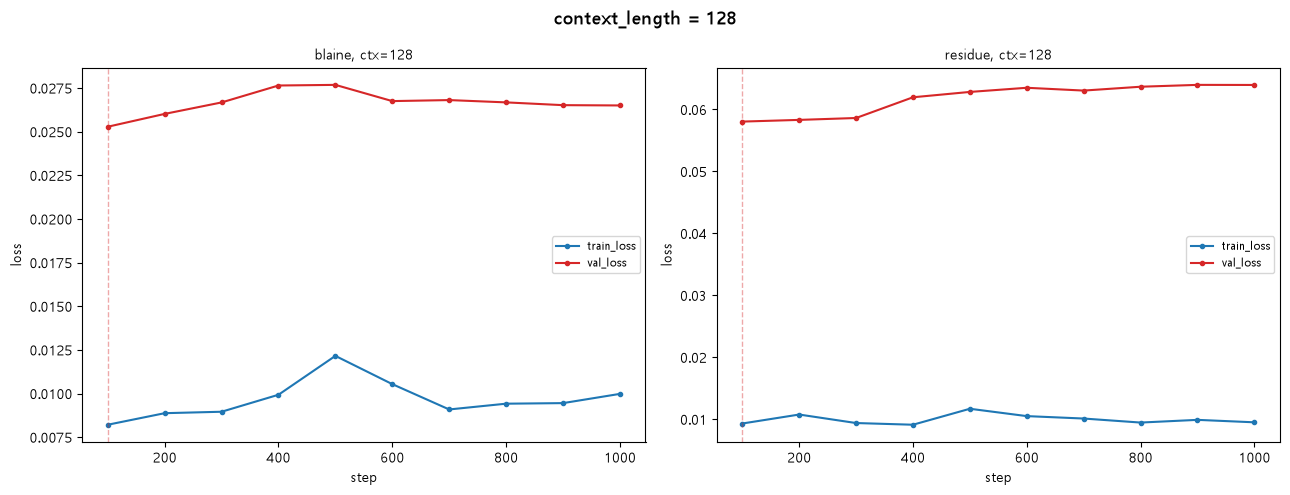

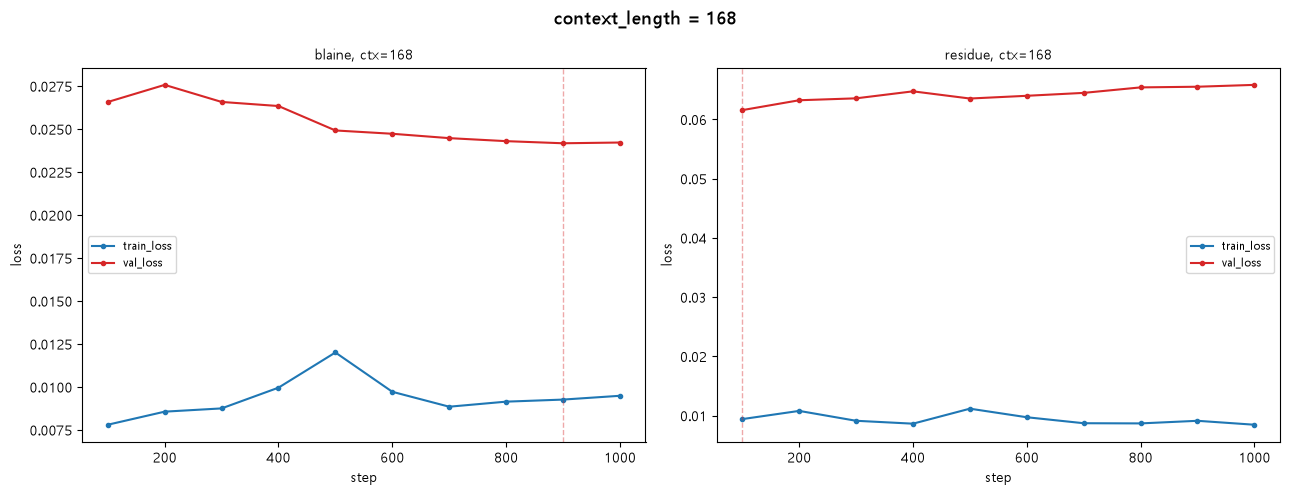

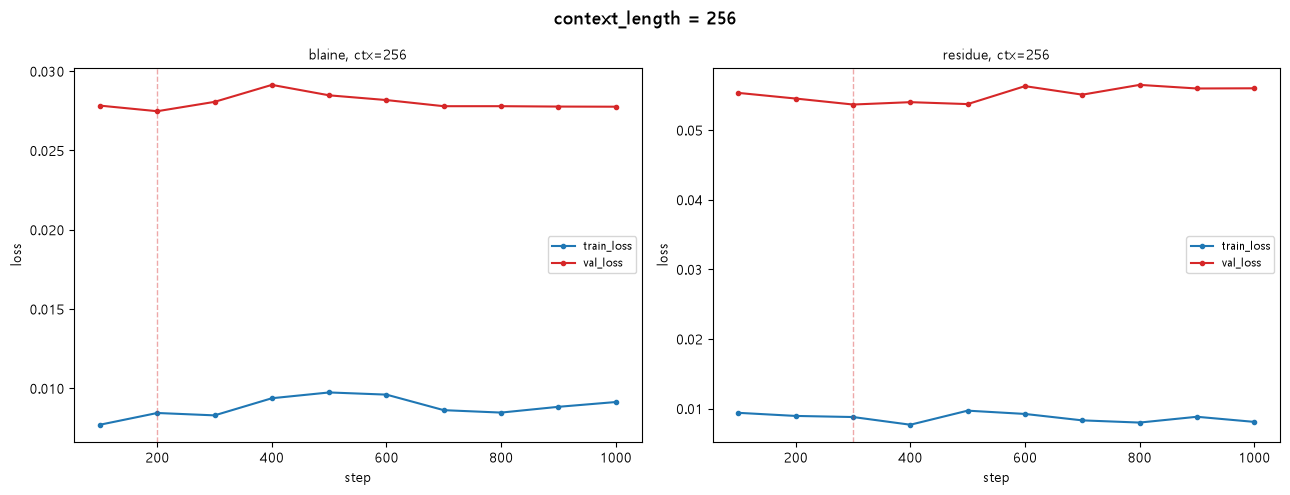

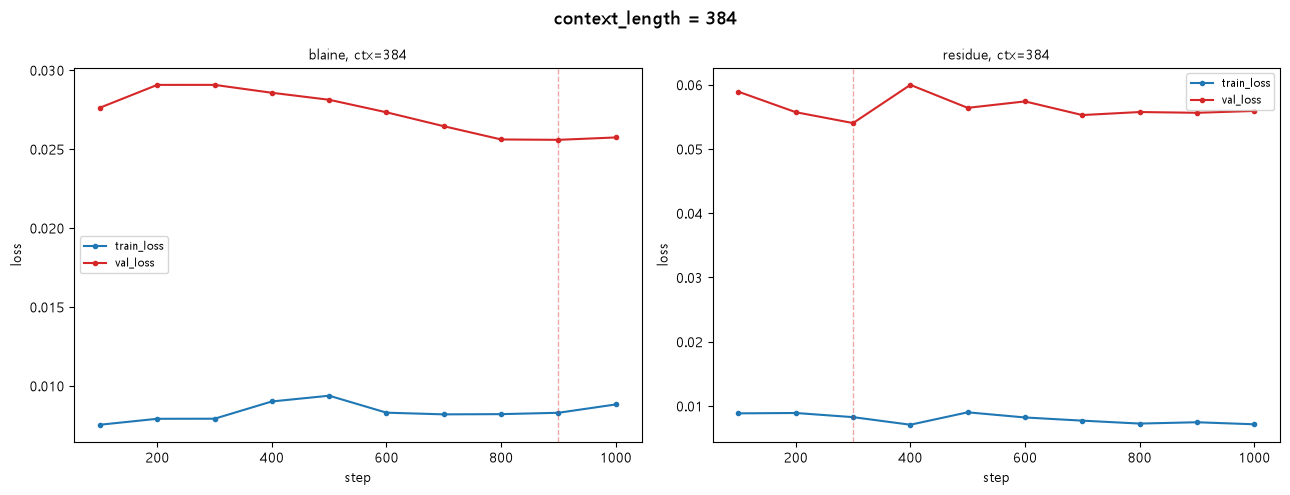

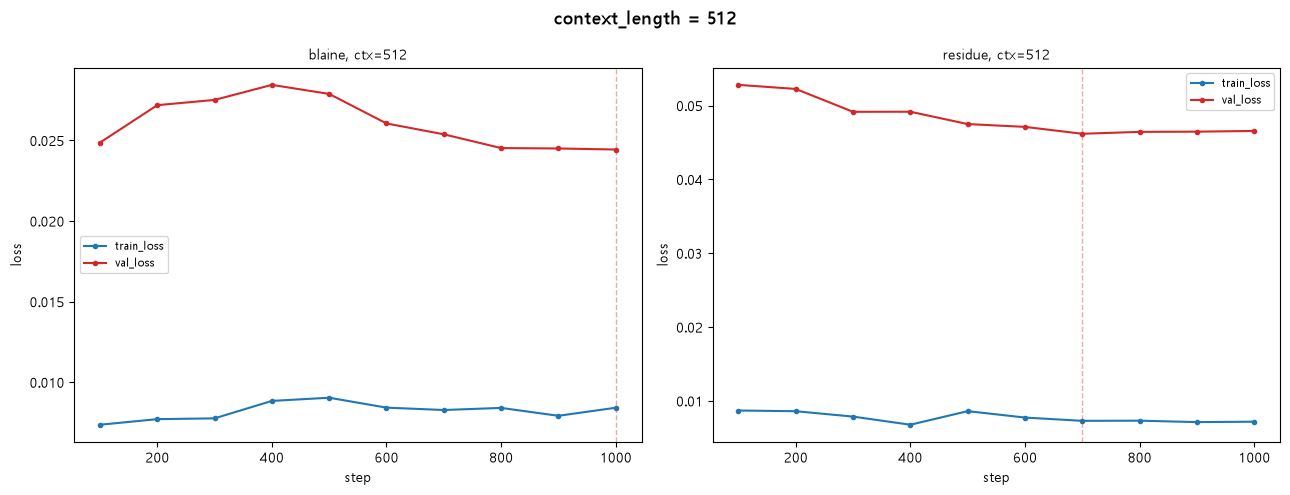

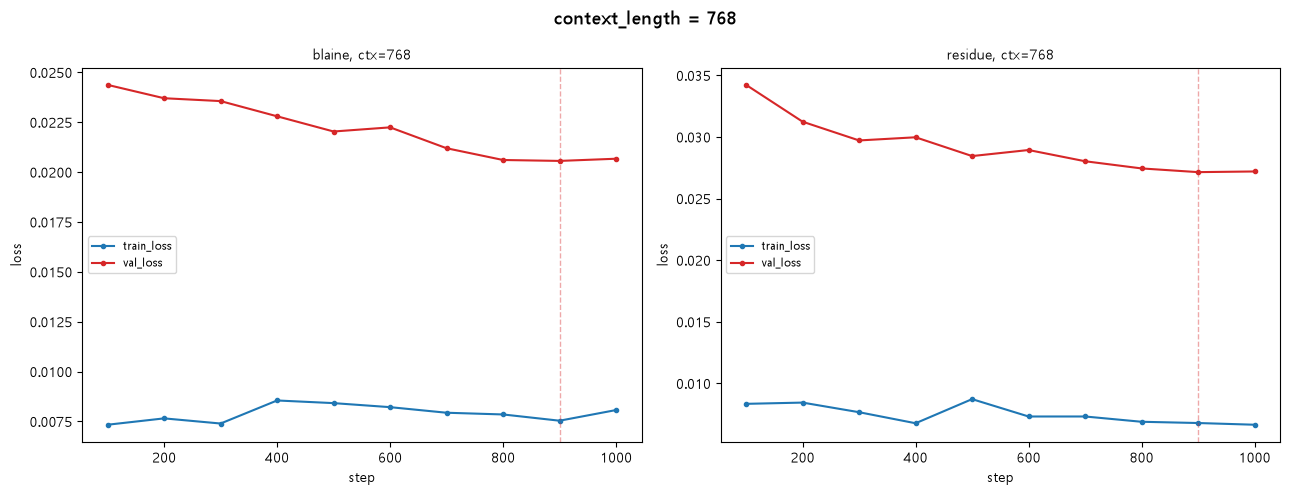

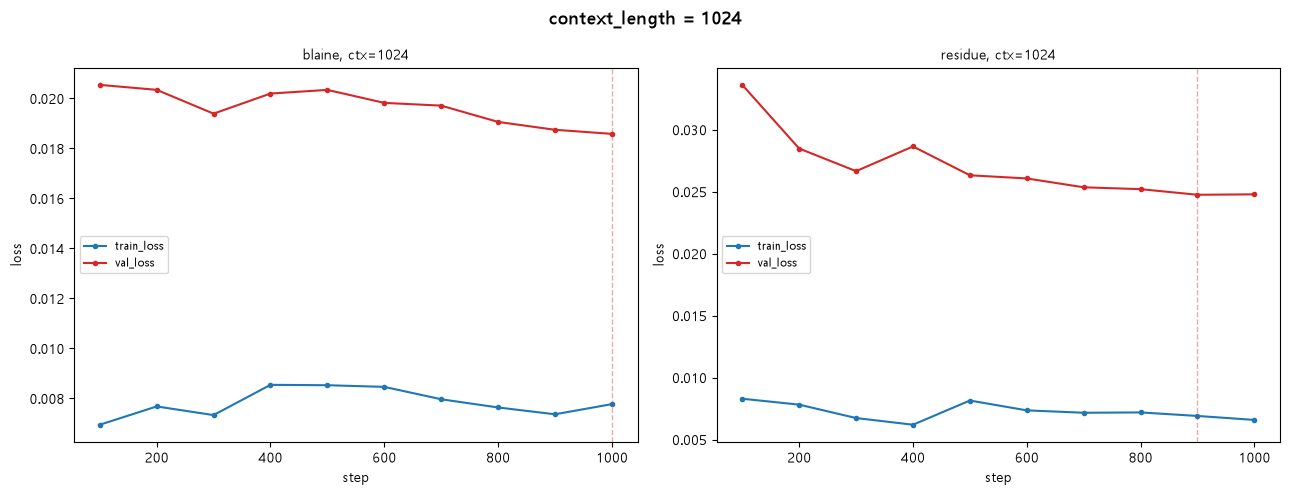

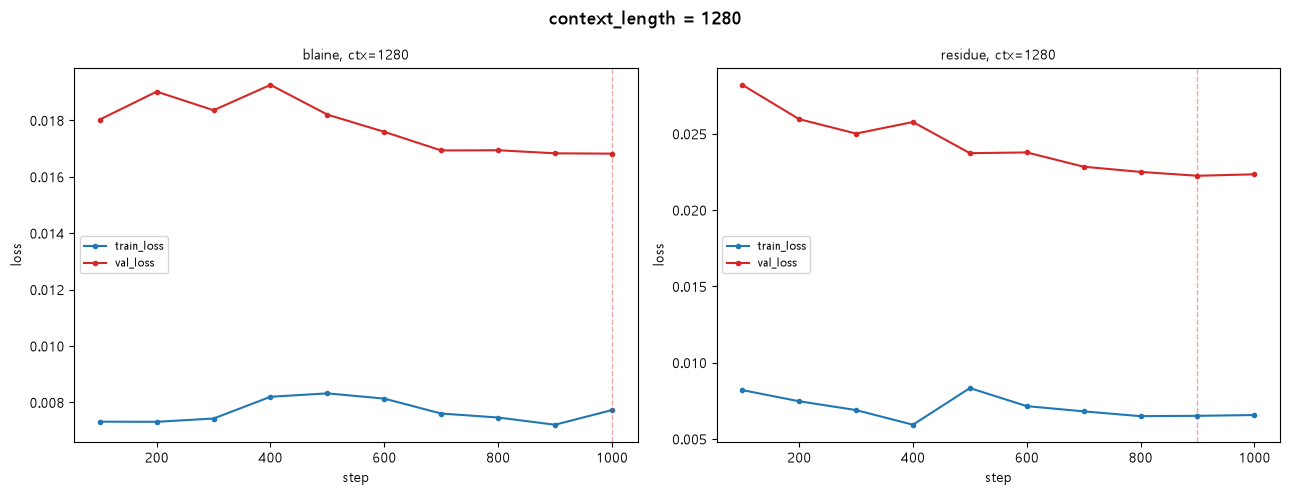

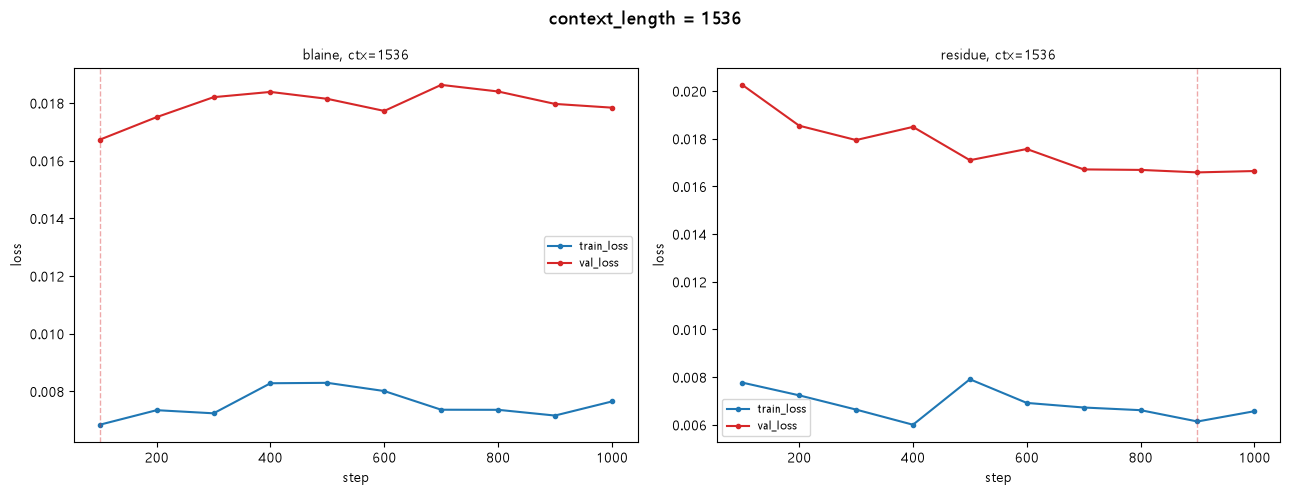

In [4]:
for ctx in CTX_VALUES:
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(6.5 * len(TARGETS), 5))
    for ax, target in zip(axes, TARGETS):
        df = loss_dfs.get((target, ctx))
        if df is None:
            ax.set_visible(False)
            continue
        plot_loss_history(df, ax=ax, title=f"{target}, ctx={ctx}")
    fig.suptitle(f"context_length = {ctx}", fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()

## 4. 결론

(2026-08-21, `_v2` 스윕 22개 run 완료 후 직접 확인한 결과 — 1280/1536 추가 반영)

**512 이상 구간, blaine/residue val_min 비교:**

| ctx | blaine val_min | 도달 step | residue val_min | 도달 step |
|---|---|---|---|---|
| 512 | 0.0244 | 1000(끝) | 0.0462 | 700 |
| 768 | 0.0206 | 900 | 0.0271 | 900 |
| 1024 | 0.0186 | 1000(끝) | 0.0247 | 900 |
| **1280** | **0.0168** | **1000(끝)** | 0.0223 | 900 |
| 1536 | 0.0167 | **100(시작!)** | **0.0166** | 900 |

**핵심 결론: blaine과 residue가 1280~1536 구간에서 서로 다르게 반응합니다.**

- **residue**: 512→768→1024→1280→1536 내내 `val_min`이 끝(또는 끝 근처, step 700~900)에서 나오며
  **한 번도 끊기지 않고 계속 개선**됩니다. 지금까지 시도한 범위 안에서는 클수록 계속 좋습니다.
- **blaine**: **1280까지는 residue와 똑같이 안정적으로 계속 개선**(1024보다도 낮은 0.0168을 마지막
  step에서 달성)되다가, **1536에서 처음으로 불안정해집니다**(최저점이 시작하자마자인 step 100에서
  나오고 이후 다시 그 수준을 못 찾음). 즉 **경계가 1280과 1536 사이에 있다는 게 이번에 확인됐습니다.**
- 그래서 **blaine 기준 실전에서 쓸 만한 최선의 context_length는 1280**입니다 — 1024보다 명확히
  낫고(val_min -9.7%), 1536처럼 불안정하지도 않습니다.

**남은 불확실성**: 1280과 1536 사이(예: 1408) 어디서 정확히 꺾이는지는 아직 안 봤고, residue가
1536 이후(예: 2048)에도 계속 좋아질지도 미확인 — 2048은 이 GPU에서 step당 시간이 8배로 튀어서
(1.6초→12.4초) 아직 정식 학습 안 함.

---

**아래는 이전(2026-08-20, 18개 run 기준) 관찰 — context_length가 작을수록(73/128/168) 뚜렷하게
overfitting, 클수록(512 이상) 없음:**

- overfitting이 뚜렷한 4개 조합(residue 128/168/73, blaine 73) 전부 **`val_min_step=100`**, 즉 학습을
  시작하자마자(첫 평가 시점)에 최저점을 찍고, 그 뒤 900 step 내내 계속 나빠지기만 했습니다. context가
  짧아서 모델이 금방 "외워버리고" 이후로는 train loss만 계속 낮아지면서 val loss는 반등하는, 교과서적인
  overfitting 곡선입니다(residue ctx=128 그래프 참고).
- 이 결과는 `results_context_comparison.ipynb`가 MAE 기준으로 이미 내렸던 결론(**512/768/1024가 상위권,
  73/128/168이 하위권**)과 완전히 같은 방향입니다.
- 예전 `_v2` 이전 버전에서 점이 1개뿐이라 판단 불가능했던 조합들(blaine ctx=73, residue ctx=128/168)이
  바로 이번에 **가장 뚜렷하게 overfitting하는 것으로 확인된 조합들**이었다는 점도 주목할 만합니다.